## Deakin University

## SIG731- Data Wrangling

**Name:** Surendra Bahadur Rai

**Email:** s223940212@deakin.com

**Student ID:** s223940212

## Task 3P

**Objective**

This task aims to analyze, compare, and interpret body measurements of adult males and females based on the National Health and Nutrition Examination Survey (NHANES) dataset. The study focuses on understanding key characteristics such as height, weight, waist circumference, hip circumference, and BMI. Data visualization techniques and statistical summaries are employed to explore and explain these measurements.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import skew
import matplotlib.pyplot as plt
import itertools

import warnings
warnings.filterwarnings('ignore')

###  Q1. From https://github.com/gagolews/teaching-data/tree/master/marek, download the two following excerpts from the National Health and Nutrition Examination Survey (NHANES dataset)

Donloaded File 'nhanes_adult_female_bmx_2020.csv' and 'nhanes_adult_male_bmx_2020.csv' from github url and then locally store the file the  some unwanted content cleanup then  reading using numpy libray and pandas libray

**DataSet infomation**

- Weight (kg)
- Standing Height (cm)
- Upper Arm Length (cm)
- Upper Leg Length (cm)
- Arm Circumference (cm)
- Hip Circumference (cm)
- Waist Circumference (cm)

### Load the CSV files using numpy

In [2]:
# Load the CSV files and read using numpy as matrix format
data_female = np.genfromtxt('nhanes_adult_female_bmx_2020.csv', delimiter=',', skip_header=1, usecols=range(7), 
    dtype=float, encoding='utf-8')
data_male = np.genfromtxt('nhanes_adult_male_bmx_2020.csv', delimiter=',', skip_header=1, usecols=range(7), 
    dtype=float, encoding='utf-8')

print("Numpy - Female Data first 5 rows:")
print(data_female[:5]) 

print("Numpy - Male Data: first 5 rows")
print(data_male[:5]) 

ERROR! Session/line number was not unique in database. History logging moved to new session 2
Numpy - Female Data first 5 rows:
[[ 97.1 160.2  34.7  40.8  35.8 126.1 117.9]
 [ 91.1 152.7  33.5  33.   38.5 125.5 103.1]
 [ 73.  161.2  37.4  38.   31.8 106.2  92. ]
 [ 61.7 157.4  38.   34.7  29.  101.   90.5]
 [ 55.4 154.6  34.6  34.   28.3  92.5  73.2]]
Numpy - Male Data: first 5 rows
[[ 98.8 182.3  42.   40.1  38.2 108.2 120.4]
 [ 74.3 184.2  41.1  41.   30.2  94.5  86.8]
 [103.7 185.3  47.   44.   32.  107.8 109.6]
 [ 86.  167.8  39.5  38.4  29.  106.4 108.3]
 [ 99.4 181.6  40.4  39.9  36.  120.2 107. ]]


downloaded the dataset for National Health and Nutrition Examination Survey ( male and femail)
show the numpy Matrix array format top 5 rows uning numpy libray

**Data set have 7 columns and 6 index:**

**Here Femel Dataset**

- data_female[:,0]= BMXWT = Weight (kg)
- data_female[:,1]= BMXHT = Standing Height (cm)
- data_female[:,2]= BMXARML = Upper Arm Length (cm)
- data_female[:,3]= BMXLEG = Upper Leg Length (cm)
- data_female[:,4]= BMXARMC = Arm Circumference (cm)
- data_female[:,5]= BMXHIP = Hip Circumference (cm)
- data_female[:,6]= BMXWAIST = Waist Circumference (cm)

**Similar as Male Dataset**

- data_male[:,0]= BMXWT = Weight (kg)
- data_male[:,1]= BMXHT = Standing Height (cm)
- data_male[:,2]= BMXARML = Upper Arm Length (cm)
- data_male[:,3]= BMXLEG = Upper Leg Length (cm)
- data_male[:,4]= BMXARMC = Arm Circumference (cm)
- data_male[:,5]= BMXHIP = Hip Circumference (cm)
- data_male[:,6]= BMXWAIST = Waist Circumference (cm)
- 

### Load the CSV files using panda dataframe

In [3]:
# Load the CSV files using panda dataframe
df_female = pd.read_csv('nhanes_adult_female_bmx_2020.csv',engine='python')
df_male= pd.read_csv('nhanes_adult_male_bmx_2020.csv', engine='python')

#showing output  top 5 reacord using head() method
df_female.head(), df_male.head()

(   BMXWT  BMXHT  BMXARML  BMXLEG  BMXARMC  BMXHIP  BMXWAIST
 0   97.1  160.2     34.7    40.8     35.8   126.1     117.9
 1   91.1  152.7     33.5    33.0     38.5   125.5     103.1
 2   73.0  161.2     37.4    38.0     31.8   106.2      92.0
 3   61.7  157.4     38.0    34.7     29.0   101.0      90.5
 4   55.4  154.6     34.6    34.0     28.3    92.5      73.2,
    BMXWT  BMXHT  BMXARML  BMXLEG  BMXARMC  BMXHIP  BMXWAIST
 0   98.8  182.3     42.0    40.1     38.2   108.2     120.4
 1   74.3  184.2     41.1    41.0     30.2    94.5      86.8
 2  103.7  185.3     47.0    44.0     32.0   107.8     109.6
 3   86.0  167.8     39.5    38.4     29.0   106.4     108.3
 4   99.4  181.6     40.4    39.9     36.0   120.2     107.0)

As same i have use pandas libray to read National Health and Nutrition Examination Survey ( male and femail) and showing the top 5 records

In [4]:
# Display the structure of each dataset to understand the available columns
print("Columns in Female Dataset:", df_female.columns)
print("Columns in Male Dataset:", df_male.columns)
print("Data shape of Femal:",df_female.shape)
print("Data shape of Male:",df_male.shape)

Columns in Female Dataset: Index(['BMXWT', 'BMXHT', 'BMXARML', 'BMXLEG', 'BMXARMC', 'BMXHIP', 'BMXWAIST'], dtype='object')
Columns in Male Dataset: Index(['BMXWT', 'BMXHT', 'BMXARML', 'BMXLEG', 'BMXARMC', 'BMXHIP', 'BMXWAIST'], dtype='object')
Data shape of Femal: (4221, 7)
Data shape of Male: (4081, 7)


In [5]:
# Body measurements
female_measurements = df_female[['BMXWT', 'BMXHT']].head()
male_measurements = df_male[['BMXWT', 'BMXHT',]].head()

# Calculate BMI for female and male for
female_measurements['BMI'] = female_measurements['BMXWT'] / (df_female['BMXHT'] / 100) ** 2  
male_measurements['BMI'] = male_measurements['BMXWT'] / (df_male['BMXHT'] / 100) ** 2 

print("\nBody Measurements of Adult Females:")
print(female_measurements)

print("\nBody Measurements of Adult Males:")
print(male_measurements)


Body Measurements of Adult Females:
   BMXWT  BMXHT        BMI
0   97.1  160.2  37.835041
1   91.1  152.7  39.069720
2   73.0  161.2  28.092655
3   61.7  157.4  24.904378
4   55.4  154.6  23.178791

Body Measurements of Adult Males:
   BMXWT  BMXHT        BMI
0   98.8  182.3  29.729226
1   74.3  184.2  21.898258
2  103.7  185.3  30.201459
3   86.0  167.8  30.543200
4   99.4  181.6  30.140795


- First I read from dataframe  body wight and Height of male and femels
- Calculate the BMI Using bellow formula and add New Colum of dataset BMI:

    **(Body mass index) of male and femel :**  
$$
BMI=\frac{ Weight (kg)}{(Height (m))^2 }
$$
- showing the male and femel Body Meserments


### Q2. Read them as numpy matrices named male and female using numpy.genfromtxt. Each matrix consists of seven columns:

In [6]:
# Again to Load the CSV files and read using numpy as matrix format
data_female = np.genfromtxt('nhanes_adult_female_bmx_2020.csv', delimiter=',', skip_header=1, usecols=range(7), 
    dtype=float, encoding='utf-8')
data_male = np.genfromtxt('nhanes_adult_male_bmx_2020.csv', delimiter=',', skip_header=1, usecols=range(7), 
    dtype=float, encoding='utf-8')


print("Femal Data:", data_male)
print("Male Data:", data_male)

# Function to calculate BMI
def calculate_bmi(weight, height_cm):
    height_m = height_cm / 100
    return weight / (height_m ** 2)


# Calculate BMI for males and females
male_bmi = calculate_bmi(data_male[:, 0], data_male[:, 1])  # Weight is column 1, height is column 2
female_bmi = calculate_bmi(data_female[:, 0], data_female[:, 1])  # Weight is column 1, height is column 2

# Add BMI as a new column to the matrices
male_with_bmi = np.column_stack((data_male, male_bmi))
female_with_bmi = np.column_stack((data_female, female_bmi))

# Print the resulting matrices with BMI
print("Male Data Matrix with BMI (First 5 rows):")
print(male_with_bmi[:5])  # Display the first 5 rows

print("\nFemale Data Matrix with BMI (First 5 rows):")
print(female_with_bmi[:5])  # Display the first 5 rows

Femal Data: [[ 98.8 182.3  42.  ...  38.2 108.2 120.4]
 [ 74.3 184.2  41.1 ...  30.2  94.5  86.8]
 [103.7 185.3  47.  ...  32.  107.8 109.6]
 ...
 [108.8 168.7  38.6 ...  33.6 118.  114.7]
 [ 79.5 176.4  39.5 ...  31.4  99.8  97.1]
 [ 59.7 167.5  40.3 ...  29.2  90.5  86.9]]
Male Data: [[ 98.8 182.3  42.  ...  38.2 108.2 120.4]
 [ 74.3 184.2  41.1 ...  30.2  94.5  86.8]
 [103.7 185.3  47.  ...  32.  107.8 109.6]
 ...
 [108.8 168.7  38.6 ...  33.6 118.  114.7]
 [ 79.5 176.4  39.5 ...  31.4  99.8  97.1]
 [ 59.7 167.5  40.3 ...  29.2  90.5  86.9]]
Male Data Matrix with BMI (First 5 rows):
[[ 98.8        182.3         42.          40.1         38.2
  108.2        120.4         29.72922633]
 [ 74.3        184.2         41.1         41.          30.2
   94.5         86.8         21.89825769]
 [103.7        185.3         47.          44.          32.
  107.8        109.6         30.20145858]
 [ 86.         167.8         39.5         38.4         29.
  106.4        108.3         30.54320016]
 


- Load the CSV files and read using numpy as matrix format
- Create function calculate_bmi(wight, height) which will calculate BMI
- Calculate BMI (Body Mass Index) using the formula:

$$
BMI=\frac{ Weight (kg)}{(Height (m))^2 }
$$

 - Add BMI as a new column to in to  matrices using numpy column_stack
 - Print the top 5 rows with dataset male and femels

### Q3. In both cases, add the eight column which stores the body mass indices of the participants

In [7]:
# Function to calculate BMI
def calculate_bmi(weight, height_cm):
    height_m = height_cm / 100
    return weight / (height_m ** 2)

# Calculate BMI for males and females
male_bmi = calculate_bmi(data_male[:, 0], data_male[:, 1])
female_bmi = calculate_bmi(data_female[:, 0], data_female[:, 1])

# Add BMI as a new column to the matrices
male_with_bmi = np.column_stack((data_male, male_bmi))
female_with_bmi = np.column_stack((data_female, female_bmi))

print("Male BMI:", male_with_bmi[:,7])
print("Femel BMI:",female_with_bmi[:,7])

Male BMI: [29.72922633 21.89825769 30.20145858 ... 38.22950988 25.54876826
 21.27868122]
Femel BMI: [37.83504078 39.06972037 28.09265496 ... 28.65873958 27.68361084
 37.90368801]



- Create function calculate_bmi(wight, height) which will calculate BMI
- Calculate BMI (Body Mass Index) using the formula:

$$
BMI=\frac{ Weight (kg)}{(Height (m))^2 }
$$

 - Add BMI as a new column to in to  matrices using numpy column_stack
 - Print only BMI metrix of male and femail

## Using Pandas Dataframe 

In [8]:
# Body extract measurements
female_wt_ht= df_female[['BMXWT', 'BMXHT']].head()
male_wt_ht = df_male[['BMXWT', 'BMXHT',]].head()

# Calculate BMI for female and male for
df_female['BMI'] = female_wt_ht['BMXWT'] / (female_wt_ht['BMXHT'] / 100) ** 2  
df_male['BMI'] = male_wt_ht['BMXWT'] / (male_wt_ht['BMXHT'] / 100) ** 2 
df_male,df_female

(      BMXWT  BMXHT  BMXARML  BMXLEG  BMXARMC  BMXHIP  BMXWAIST        BMI
 0      98.8  182.3     42.0    40.1     38.2   108.2     120.4  29.729226
 1      74.3  184.2     41.1    41.0     30.2    94.5      86.8  21.898258
 2     103.7  185.3     47.0    44.0     32.0   107.8     109.6  30.201459
 3      86.0  167.8     39.5    38.4     29.0   106.4     108.3  30.543200
 4      99.4  181.6     40.4    39.9     36.0   120.2     107.0  30.140795
 ...     ...    ...      ...     ...      ...     ...       ...        ...
 4076  114.3  174.5     42.0    35.5     37.0   117.4     119.5        NaN
 4077   94.3  178.8     37.8    44.6     35.7   105.3      99.3        NaN
 4078  108.8  168.7     38.6    45.6     33.6   118.0     114.7        NaN
 4079   79.5  176.4     39.5    42.0     31.4    99.8      97.1        NaN
 4080   59.7  167.5     40.3    41.1     29.2    90.5      86.9        NaN
 
 [4081 rows x 8 columns],
       BMXWT  BMXHT  BMXARML  BMXLEG  BMXARMC  BMXHIP  BMXWAIST        B

### Q4.On a single plot, draw two histograms: for male BMIs (top subfigure) and for female BMIs (bottom subfigure) one below another. Set the number of histogram bins to 20. Use matplotlib.pyplot.subplot to create two subplots in one figure. Call matplotlib.pyplot.xlim to make the x-axis limits identical for both subfigures

### Using matplotlib libray and drawing the histogram of  male and femail BMI

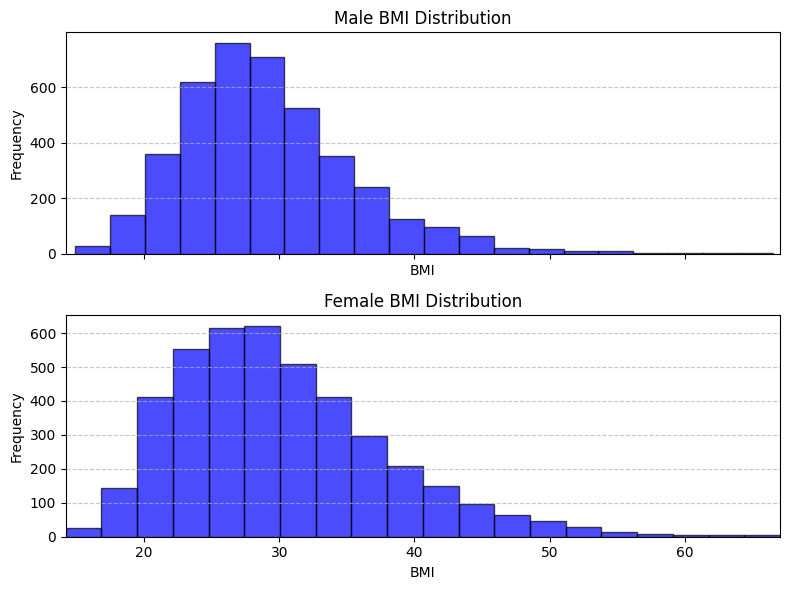

Male BMI: [29.72922633 21.89825769 30.20145858 ... 38.22950988 25.54876826
 21.27868122]
Femel BMI: [37.83504078 39.06972037 28.09265496 ... 28.65873958 27.68361084
 37.90368801]


In [9]:
# Set the figure and subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True)

# Plot the male BMI histogram
axes[0].hist(male_with_bmi[:,7], bins=20, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Male BMI Distribution')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot the female BMI histogram
axes[1].hist(female_with_bmi[:,7], bins=20, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('Female BMI Distribution')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Set identical x-axis limits for both subplots
xmin = min(np.min(male_with_bmi[:,7]), np.min(female_with_bmi[:,7]))
xmax = max(np.max(male_with_bmi[:,7]), np.max(female_with_bmi[:,7]))
plt.xlim(xmin, xmax)

# Adjust layout for better visualization
plt.tight_layout()

# Show the plot
plt.show()

#Print BMI meserment of male and femel
print("Male BMI:", male_with_bmi[:,7])
print("Femel BMI:",female_with_bmi[:,7])

**Solution:**
- Set the figure and subplots
- Plot the male BMI histogram
- Plot the female BMI histogram
- Set identical x-axis limits for both subplots
- Adjust layout for better visualization
- Print BMI meserment of male and femel

### Q5. Using a single call to matplotlib.pyplot.boxplot, draw a box-and-whisker plot giving the male and female BMIs

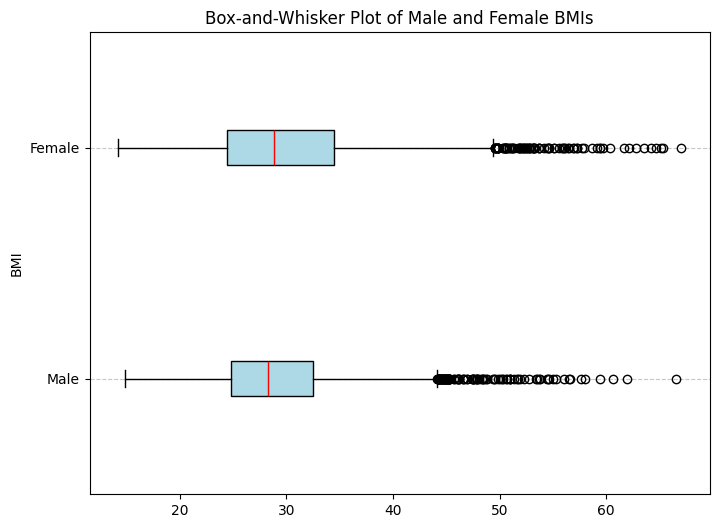

In [10]:
# Extract BMI values from male and femel
male_bmi = male_with_bmi[:,7]
femel_bmi= female_with_bmi[:,7]

# Create the boxplot
plt.figure(figsize=(8, 6))
plt.boxplot([male_bmi, femel_bmi], labels=['Male', 'Female'], patch_artist=True, 
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='red'),
            vert=False, 
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'))

# Add title and labels
plt.title('Box-and-Whisker Plot of Male and Female BMIs')
plt.ylabel('BMI')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

- Extract BMI values from male and femel
- Create the boxplot blue color and male and femel bmi dataset 
- Add title and labels

### Q6. Compute the basic numerical aggregates of the male and female BMIs (measures of location, dispersion, and shape). Report them in a readable format. Example formatting of the aggregates:

In [11]:
# Extract BMI values from male and femel
male_bmi = male_with_bmi[:,7]
femel_bmi= female_with_bmi[:,7]

# Define a function to compute aggregates
def compute_aggregates(data):
    # Calculate first quartile (Q1) and third quartile (Q3)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    # Calculate Interquartile Range (IQR)
    iqr = q3 - q1
    return {
        "mean": np.mean(data),
        "median": np.median(data),
        "min": np.min(data),
        "max": np.max(data),
        "std": np.std(data, ddof=1),
        "IQR": iqr,
        "skew": skew(data)
    }

# Compute aggregates for male and female BMIs
male_aggregates = compute_aggregates(male_bmi)
female_aggregates = compute_aggregates(femel_bmi)

# Output Formate
print("## \t \t Female \t Male")
print(f"##  \t BMI mean {female_aggregates['mean']:.2f} \t {male_aggregates['mean']:.2f}")
print(f"##  \t median\t {female_aggregates['median']:.2f} \t \t {male_aggregates['median']:.2f}")
print(f"##  \t min \t {female_aggregates['min']:.2f} \t \t {male_aggregates['min']:.2f}")
print(f"##  \t max \t {female_aggregates['max']:.2f} \t \t {male_aggregates['max']:.2f}")
print(f"##  \t std \t {female_aggregates['std']:.2f} \t \t {male_aggregates['std']:.2f}")
print(f"##  \t IQR \t {female_aggregates['IQR']:.2f} \t \t {male_aggregates['IQR']:.2f}")
print(f"##  \t skew\t {female_aggregates['skew']:.2f} \t \t {male_aggregates['skew']:.2f}")


## 	 	 Female 	 Male
##  	 BMI mean 30.10 	 29.14
##  	 median	 28.89 	 	 28.27
##  	 min 	 14.20 	 	 14.91
##  	 max 	 67.04 	 	 66.50
##  	 std 	 7.76 	 	 6.31
##  	 IQR 	 10.01 	 	 7.73
##  	 skew	 0.92 	 	 0.97


**step**
- Extract BMI values from male and femel
- Define a function to compute aggregates
- Compute aggregates for male and female BMIs
- Printting the agregates function  mean, median min, max, std and IQR and Skew result

### Q7.In your own words, describe the two distributions based on the results obtained in subtasks Q4, Q5, and Q6 above (e.g., are they left-skewed, how they differ, which one has more dispersion, and so forth)

### Explanation:

**Male BMI Distribution:**

The skewness value for males indicates a slight right-skew (positive skew), meaning the distribution has a longer tail on the right. Most males have BMIs clustered around the median, but a few have significantly higher BMIs, pulling the tail to the right.

**Female BMI Distribution:**

Similarly, the female BMI distribution is slightly right-skewed, but the skewness value is lower than males, suggesting less asymmetry. There are still a few individuals with higher BMIs, but the concentration around the median is slightly tighter compared to males.


**Location (Central Tendency mean):**

- The mean BMI for females (30.10) is slightly higher than for males (29.14), indicating that on average, females have slightly higher BMIs than males.
- The median BMI for both males (28.27) and females (28.89) is similar, showing the central tendency of the two distributions is comparable.

**Dispersion (Spread) Q6:**

The standard deviation (std) and interquartile range (IQR) for females are higher than for males:
- Female $BMI: std = 7.76, IQR = 10.01.$
- Male $BMI: std = 6.31, IQR = 7.73.$

This indicates that female BMI values are more spread out and show greater variability compared to males.
The range (min to max) is slightly larger for females, further supporting that females have a wider dispersion of BMIs.

**(Boxplot Observations & Outliers Q5):**

Both distributions show the presence of outliers on the higher end of the BMI scale, as seen in the boxplot. However, females tend to have more extreme outliers, likely contributing to their higher skewness and dispersion.

***Comparison of Histograms (Q4)**

The histograms of male and female BMIs show a similar bell-shaped distribution but with subtle differences:
- The female histogram is slightly flatter and wider, reflecting greater variability.
- The male histogram is slightly taller and narrower, suggesting a more concentrated distribution.

### Q8. Draw a scatterplot matrix (pairplot) for the male heights, weights, waist circumferences, hip circumferences, and BMIs (these five columns only);

In [12]:
#Rename the Colum and subset and filter 
male_df_rename = df_male.rename(columns={"BMXWT": "Height", "BMXHT": "Weight","BMXWAIST":"Waist","BMXHIP":"Hip"})

In [13]:
#Colum Filter and subset of male dataset
columns = ['Height', 'Weight', 'Waist', 'Hip', 'BMI']
male_df_subset = male_df_rename[columns]

### Seaborn libray Grapha

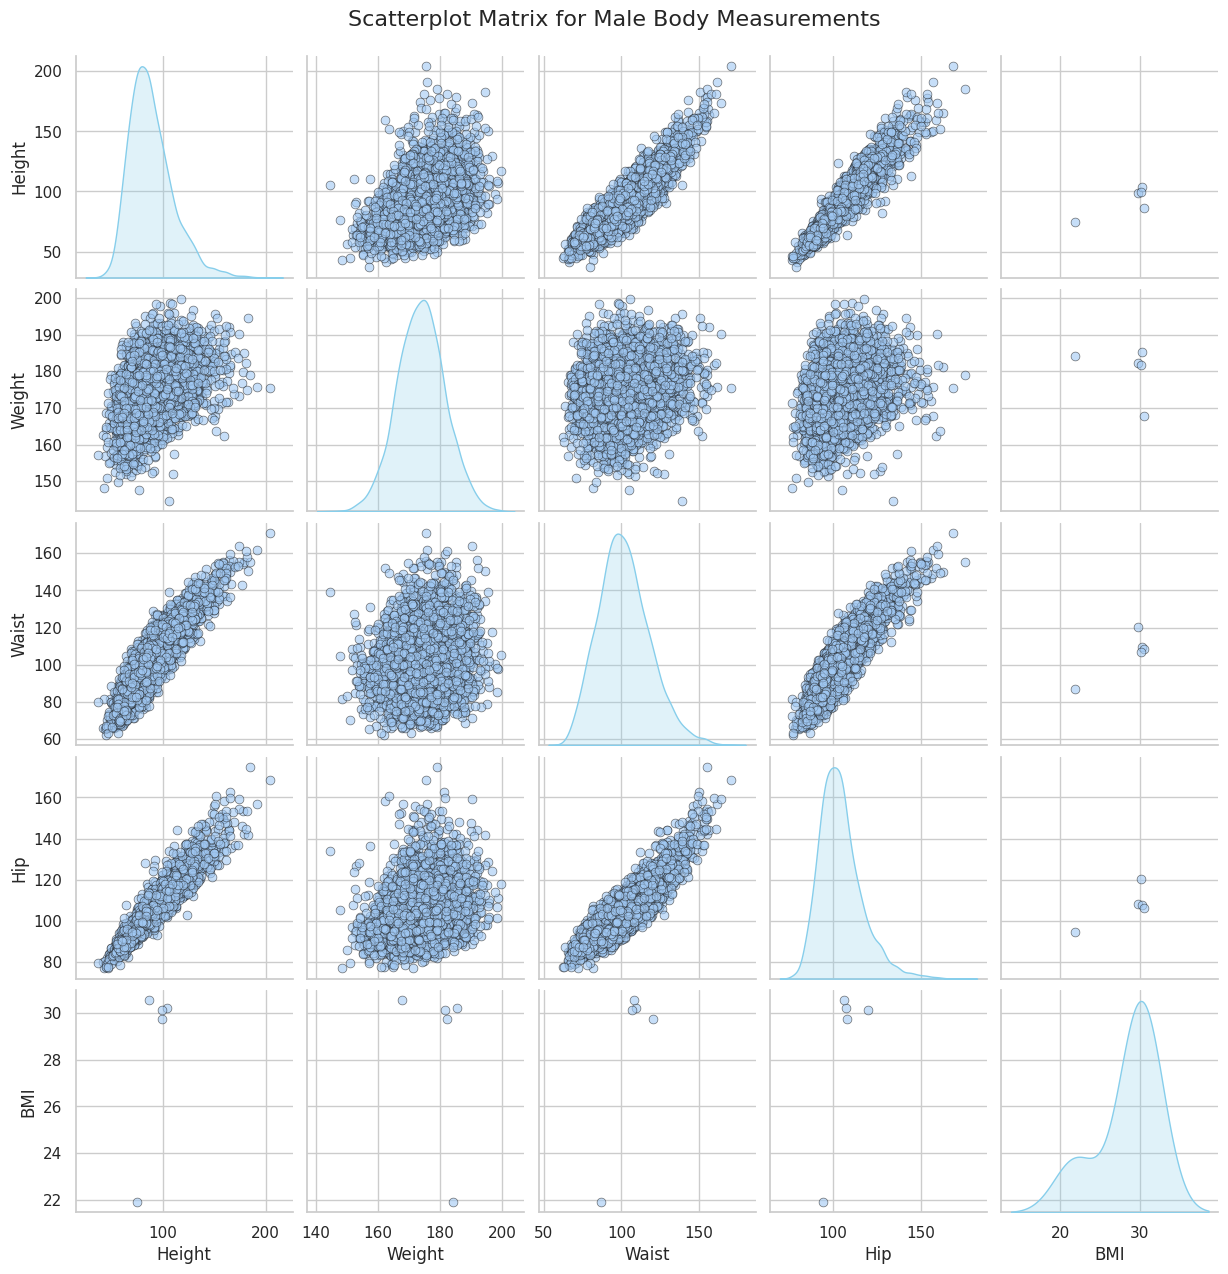

,Height,Weight,Waist,Hip,BMI
0,98.8,182.3,120.4,108.2,29.729226
1,74.3,184.2,86.8,94.5,21.898258
2,103.7,185.3,109.6,107.8,30.201459
3,86.0,167.8,108.3,106.4,30.543200
4,99.4,181.6,107.0,120.2,30.140795
...,...,...,...,...,...
4076,114.3,174.5,119.5,117.4,NaN
4077,94.3,178.8,99.3,105.3,NaN
4078,108.8,168.7,114.7,118.0,NaN
4079,79.5,176.4,97.1,99.8,NaN


In [14]:
# Create a pairplot
sns.set(style="whitegrid", palette="pastel")
pairplot = sns.pairplot(
    male_df_subset,
    diag_kind="kde",
    plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'k'},
    diag_kws={'shade': True, 'color': 'skyblue'} 
)

# Add a title
pairplot.fig.suptitle("Scatterplot Matrix for Male Body Measurements", y=1.02, fontsize=16)
# Show the plot
plt.show()
male_df_subset

Here:
Rename the Colum and subset and filter 

**Columns filter**

- Height
- Weight
- Waist circumference
- Hip circumference
- BMI

**Plotting paiplot using seabon libray**

The pairplot function provided a matrix of scatterplots, showing the relationships between each pair of these variables. The diagonal of the plot showed the distribution of each variable, and the off-diagonal plots displayed scatter plots representing the relationships between each pair.


### Only Matplotlib libray Grapha

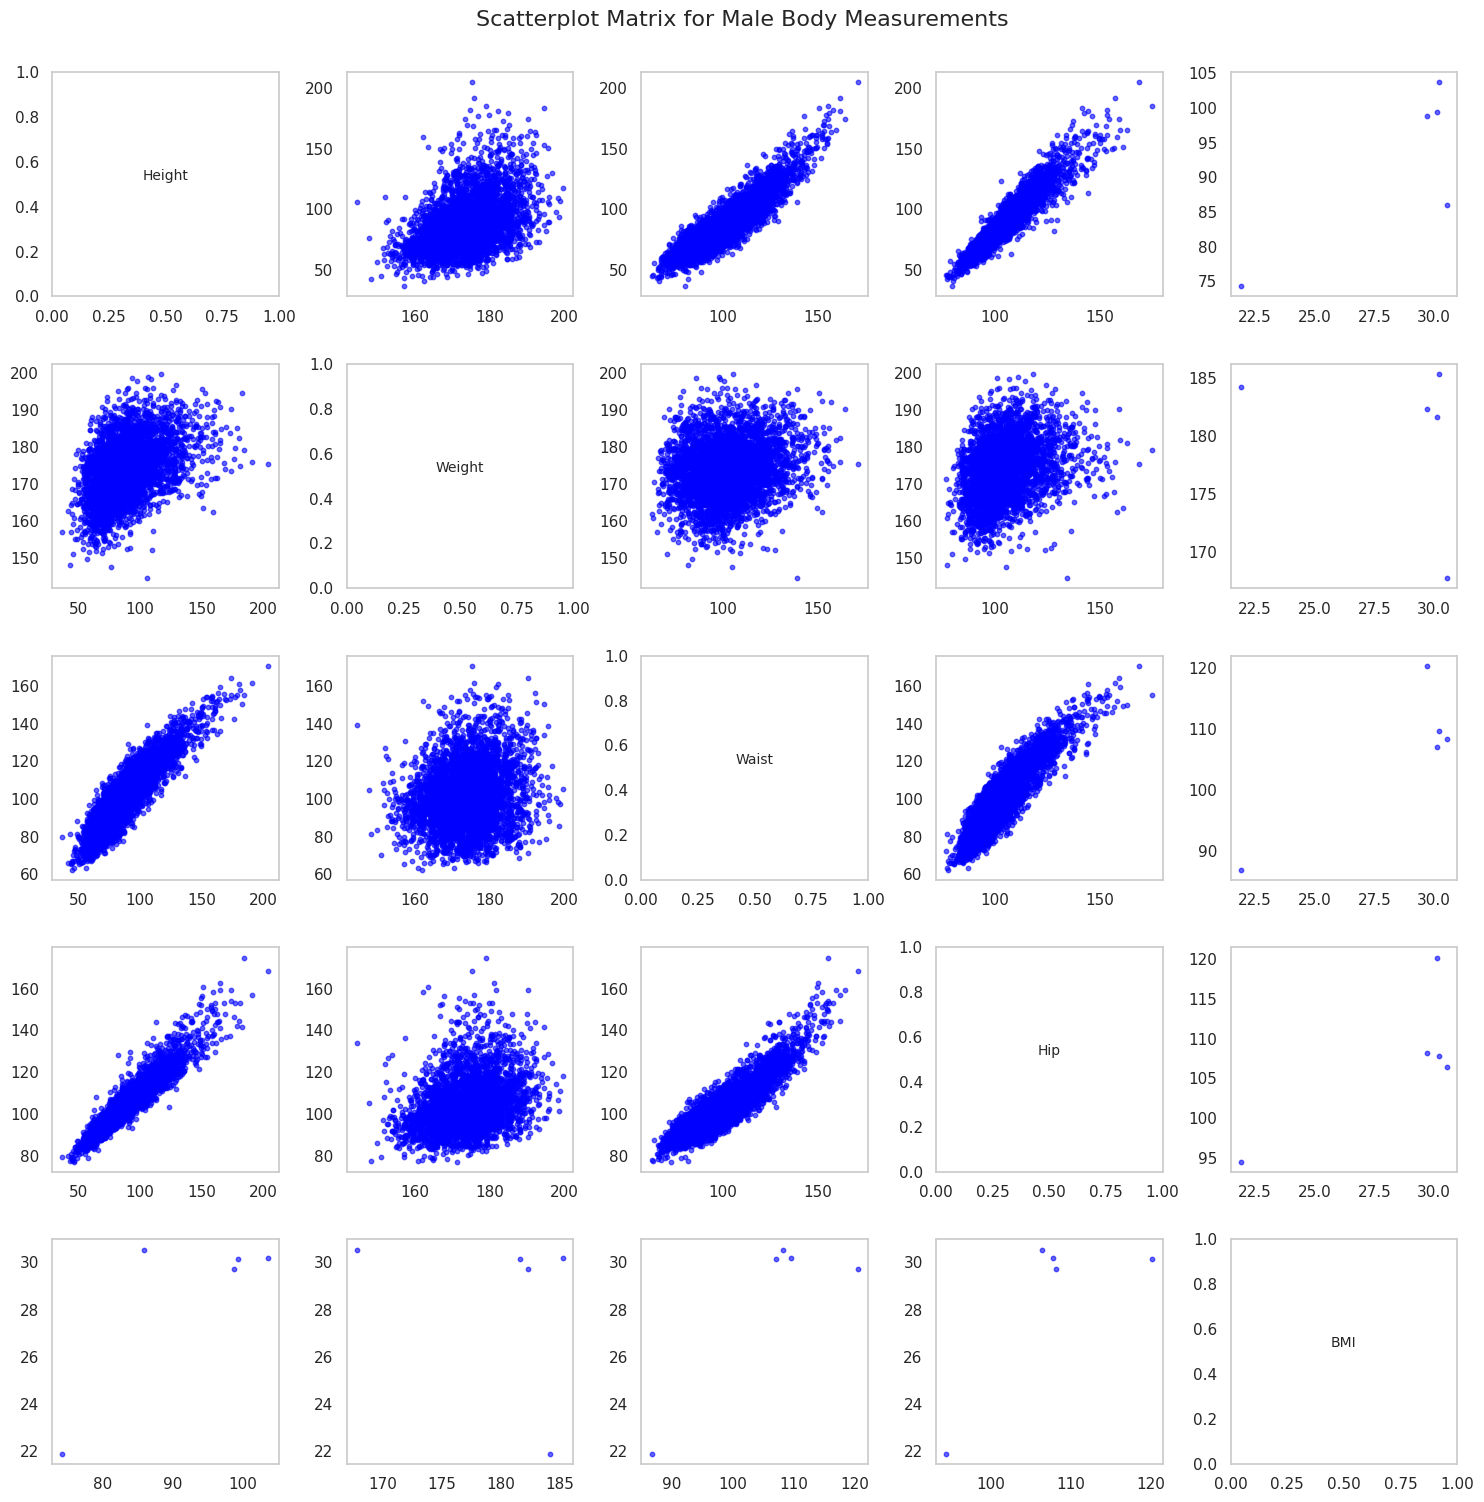

In [15]:
# Create a scatterplot matrix
num_vars = len(columns)
fig, axes = plt.subplots(num_vars, num_vars, figsize=(15, 15))
fig.suptitle('Scatterplot Matrix for Male Body Measurements', fontsize=16, y=1)

# Loop to plot histograms and scatterplots
for i, j in itertools.product(range(num_vars), repeat=2):
    if i == j:
        # Plot histograms on the diagonal
        #axes[i, j].hist(male_df_subset.iloc[:, i], bins=20, color='skyblue', edgecolor='black')
        axes[i, j].set_title(columns[i], fontsize=10,  va='center', y=0.5)
    else:
        # Plot scatterplots on the off-diagonal
        axes[i, j].scatter(male_df_subset.iloc[:, j], male_df_subset.iloc[:, i], alpha=0.6, s=10, color='blue')
    # Remove gridlines from the Pearson heatmap
    axes[i,j].grid(False)     
    
# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)

# Show the plot
plt.show()


Here:

using matplot lib

*only taken these colums**

- Height
- Weight
- Waist circumference
- Hip circumference
- BMI

**Plotting paiplot using seabon libray**

The pairplot function provided a matrix of scatterplots, showing the relationships between each pair of these variables. The diagonal of the plot showed the distribution of each variable, and the off-diagonal plots displayed scatter plots representing the relationships between each pair.


## Q9. Compute Pearson’s and Spearman’s correlation coefficients for all pairs of variables mentioned in subtask Q8. Present/visualise these coefficients on two correlation heatmaps (with correlation coefficients printed inside the coloured cells)

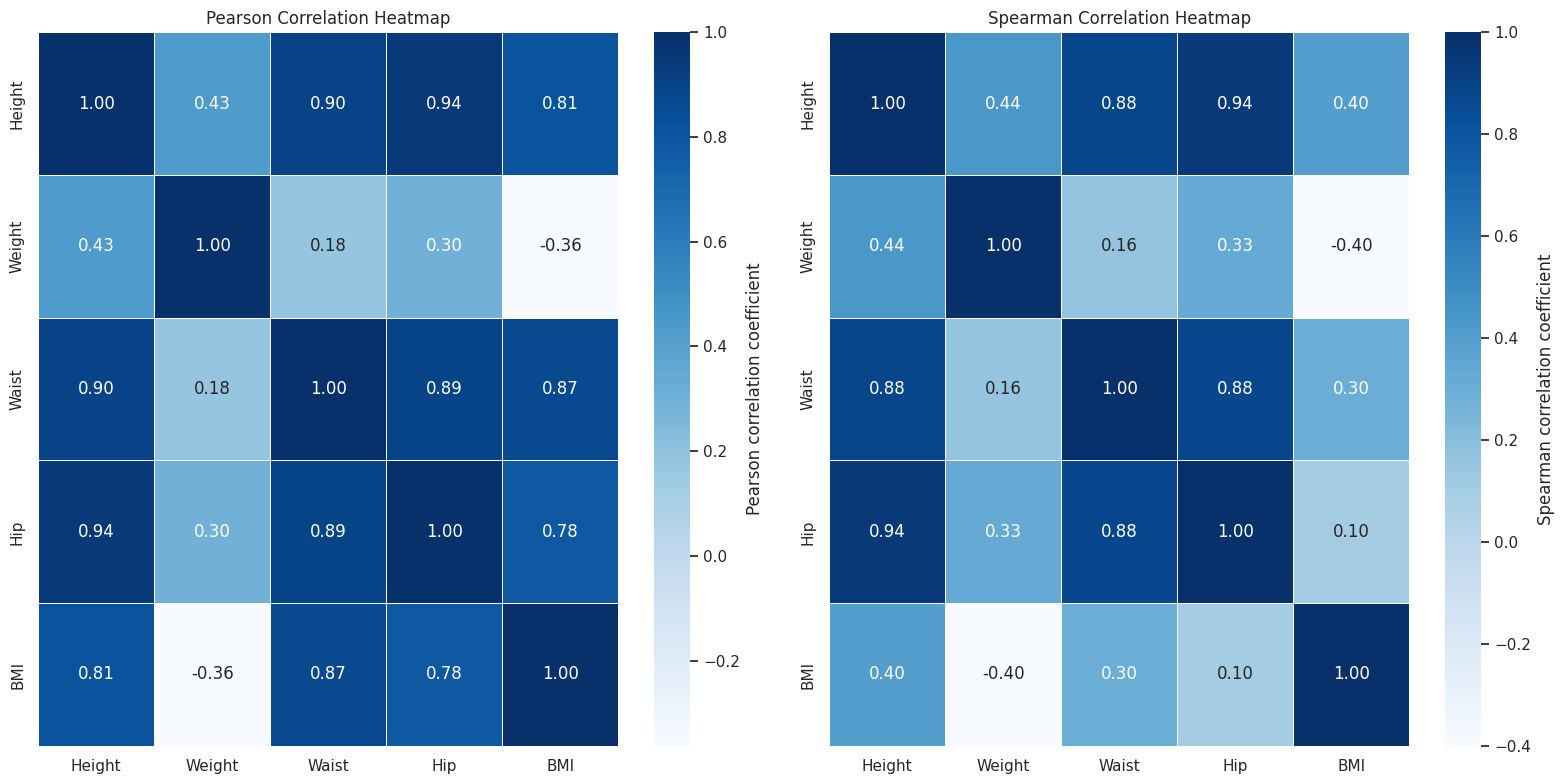

In [16]:
# Compute Pearson correlation matrix
pearson_corr = male_df_subset.corr(method='pearson')
# Compute Spearman correlation matrix
spearman_corr = male_df_subset.corr(method='spearman')
# Set up the figure for the heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
# Pearson correlation heatmap
sns.heatmap(
    pearson_corr, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    linewidths=0.5, 
    ax=axes[0], 
    cbar_kws={'label': 'Pearson correlation coefficient'}
)
axes[0].set_title('Pearson Correlation Heatmap')
# Remove gridlines from the Pearson heatmap
axes[0].grid(False)
# Spearman correlation heatmap
sns.heatmap(
    spearman_corr, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    linewidths=0.5, 
    ax=axes[1], 
    cbar_kws={'label': 'Spearman correlation coefficient'}
)
axes[1].set_title('Spearman Correlation Heatmap')
# Remove gridlines from the Pearson heatmap
axes[1].grid(False)
# Adjust layout
plt.tight_layout()
plt.show()

## Using Maptplot lib only

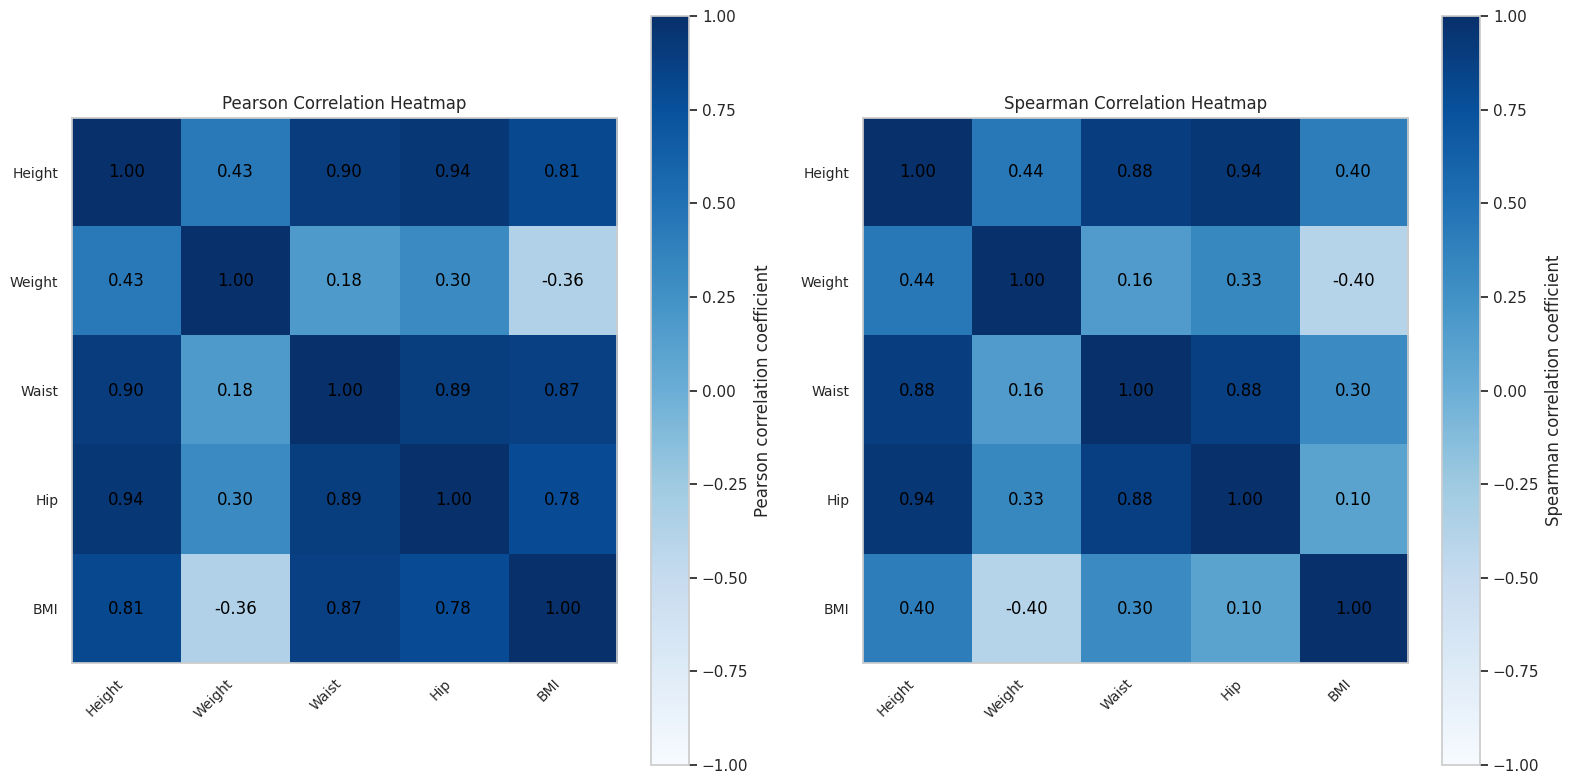

In [17]:
# Compute Pearson and Spearman correlation matrices
pearson_corr = male_df_subset.corr(method='pearson')
spearman_corr = male_df_subset.corr(method='spearman')

# Create the figure for the heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# blue color map using Matplotlib
cmap = plt.cm.Blues

# Pearson correlation heatmap using imshow()
cax1 = axes[0].imshow(pearson_corr, cmap=cmap, vmin=-1, vmax=1)
fig.colorbar(cax1, ax=axes[0], label='Pearson correlation coefficient')
axes[0].set_title('Pearson Correlation Heatmap')
axes[0].set_xticks(np.arange(len(columns)))
axes[0].set_yticks(np.arange(len(columns)))
axes[0].set_xticklabels(columns, fontsize=10, rotation=45, ha='right')
axes[0].set_yticklabels(columns, fontsize=10)
for (i, j), val in np.ndenumerate(pearson_corr):
    axes[0].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')

# Remove gridlines from the Pearson heatmap
axes[0].grid(False)

# Spearman correlation heatmap using imshow()
cax2 = axes[1].imshow(spearman_corr, cmap=cmap, vmin=-1, vmax=1)
fig.colorbar(cax2, ax=axes[1], label='Spearman correlation coefficient')
axes[1].set_title('Spearman Correlation Heatmap')
axes[1].set_xticks(np.arange(len(columns)))
axes[1].set_yticks(np.arange(len(columns)))
axes[1].set_xticklabels(columns, fontsize=10, rotation=45, ha='right')
axes[1].set_yticklabels(columns, fontsize=10)
for (i, j), val in np.ndenumerate(spearman_corr):
    axes[1].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')

# Remove gridlines from the Pearson heatmap
axes[1].grid(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Q10. Discuss the findings from subtasks Q8 and Q9.

#####  Scatterplot Matrix (Pairplot) for Male Heights, Weights, Waist Circumferences, Hip Circumferences, and BMIs In Q8, we visualized the relationships between the following variables for adult males:

- Height
- Weight
- Waist circumference
- Hip circumference
- BMI

The pairplot function provided a matrix of scatterplots, showing the relationships between each pair of these variables. The diagonal of the plot showed the distribution of each variable, and the off-diagonal plots displayed scatter plots representing the relationships between each pair.


**Height and Weight:**

There is a clear positive correlation between height and weight. Taller individuals tend to weigh more. This is typical, as height is often a good indicator of body mass, and heavier individuals generally have more body mass overall.

**Waist and Hip Circumference:** 

The relationship between waist and hip circumference shows a positive correlation, indicating that as waist size increases, hip size tends to increase as well.

**BMI and Other Variables:** 

The relationship between BMI and other variables such as height, weight, waist, and hip circumference shows an intuitive pattern. BMI, being a function of height and weight, correlates with both of these variables.



##### Pearson’s and Spearman’s Correlation Coefficients In Q9, we calculated and visualized the Pearson and Spearman correlation coefficients for all pairs of variables: Height, Weight, Waist, Hip, and BMI.

Pearson's correlation measures the linear relationship between variables. It ranges from -1 to 1, where:
 
 - 1 indicates a perfect positive linear relationship,
 - -1 indicates a perfect negative linear relationship,
 - 0 indicates no linear relationship.


Spearman's correlation measures the monotonic relationship between variables, which doesn't require the relationship to be linear but only needs the variables to move in the same direction (increasing or decreasing together).


**Pearson's Correlation:**
- **Height and Weight:** The Pearson correlation coefficient between height and weight was likely to be positive and high, confirming that taller individuals tend to have higher weight.
- Height and BMI: The Pearson correlation between height and BMI was expected to be weak or negative, as BMI tends to decrease with height due to the square of height being in the denominator.
- **Waist and Hip Circumference:** A strong positive correlation was observed here, indicating that as waist circumference increases, so does hip circumference, which is a typical trend in body measurements.

**Spearman's Correlation:**

The Spearman correlation would show similar trends but will also capture non-linear monotonic relationships. For example, even if the relationship between two variables is not strictly linear, as long as one increases while the other also increases (or decreases), Spearman will still show a high correlation.
Pearson's and Spearman's correlations for variables like BMI and Weight or Waist and Hip are likely to be very similar, since these relationships are generally monotonic as well as linear.


###  Q11. Create a new matrix zmale being a version of the male dataset with each of its eight columns standardised (by computing the z-scores of each column

In [18]:
#Calculating zmale
zmale = (male_df_subset - male_df_subset.mean()) / male_df_subset.std()
# Display the new standardized matrix
zmale.head()

,Height,Weight,Waist,Hip,BMI
0,0.487147,1.105784,1.125134,0.303386,0.331234
1,-0.656560,1.353748,-0.906210,-0.818476,-1.783395
2,0.715889,1.497306,0.472202,0.270631,0.458753
3,-0.110381,-0.786571,0.393608,0.155988,0.551035
4,0.515157,1.014429,0.315015,1.286039,0.442372


compute the z-score for each column. The formula for the z-score is:
$$
z=\frac{ X-\mu}{\delta }
$$


**Where:**

- X is the value of the element,
- μ is the mean of the column,
- σ is the standard deviation of the column.

### Q12. Perform the aforementioned subtasks Q8–Q10 on zmale instead of on the original male dataset (do not include two pairplots nor four heatmaps).

### Q8 zmale dataset pairplot using pandas

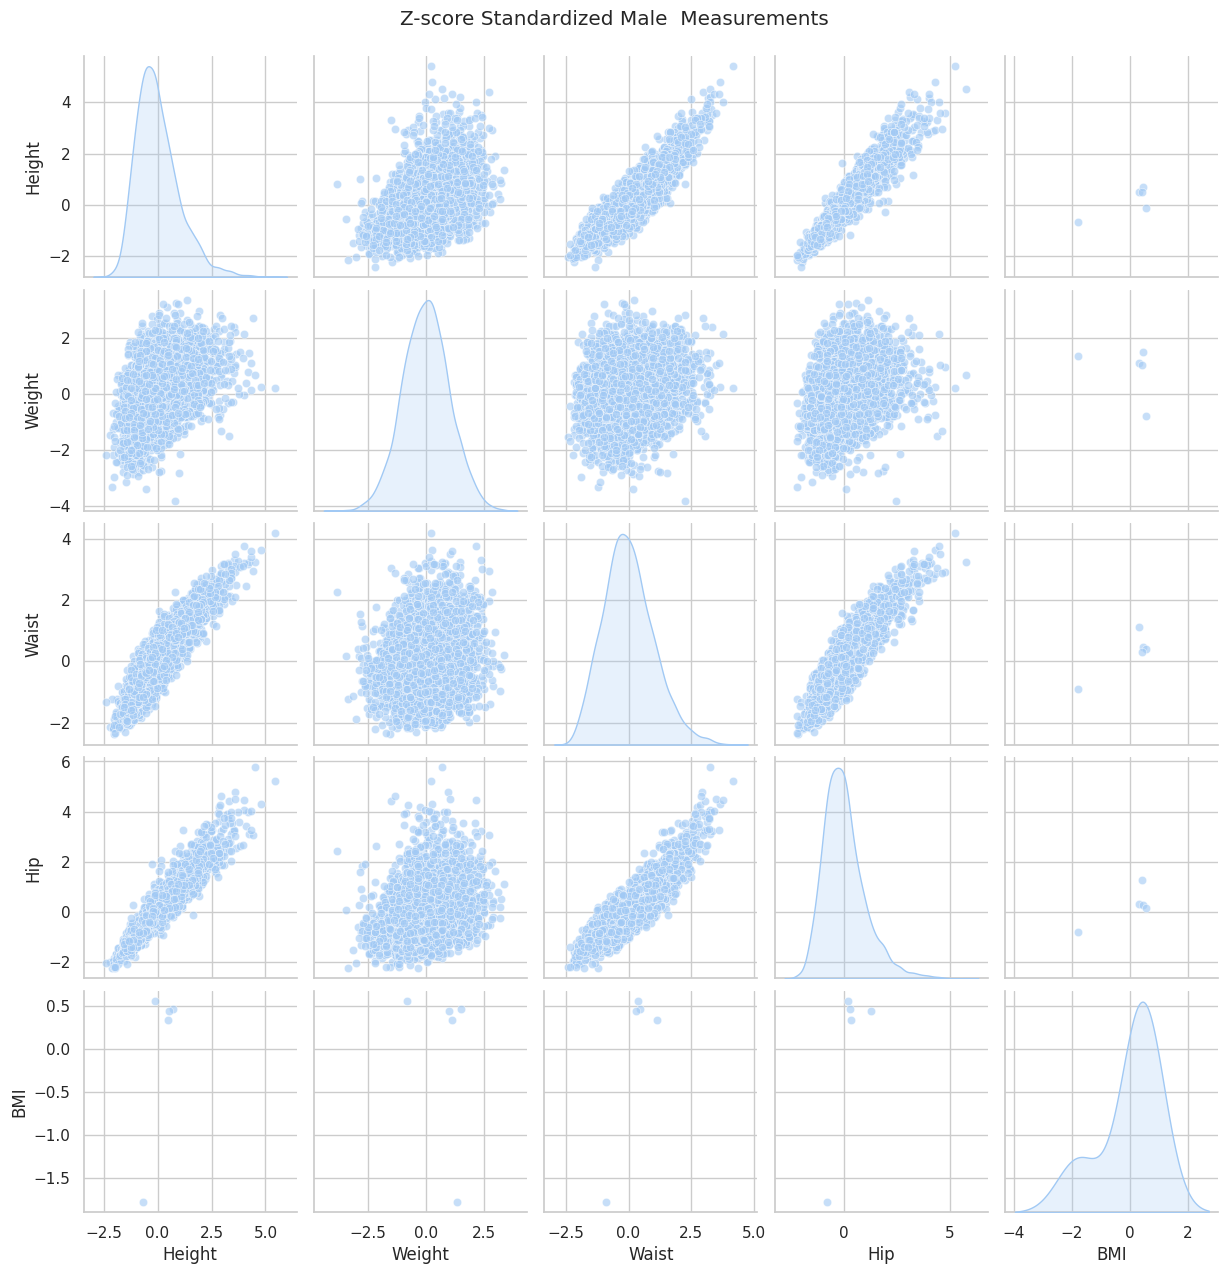

In [19]:
# Plot a pairplot using the standardized data
sns.pairplot(zmale[columns], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle("Z-score Standardized Male  Measurements", y=1.02)
plt.show()

### Q8 zmale dataset pairplot using Numpay

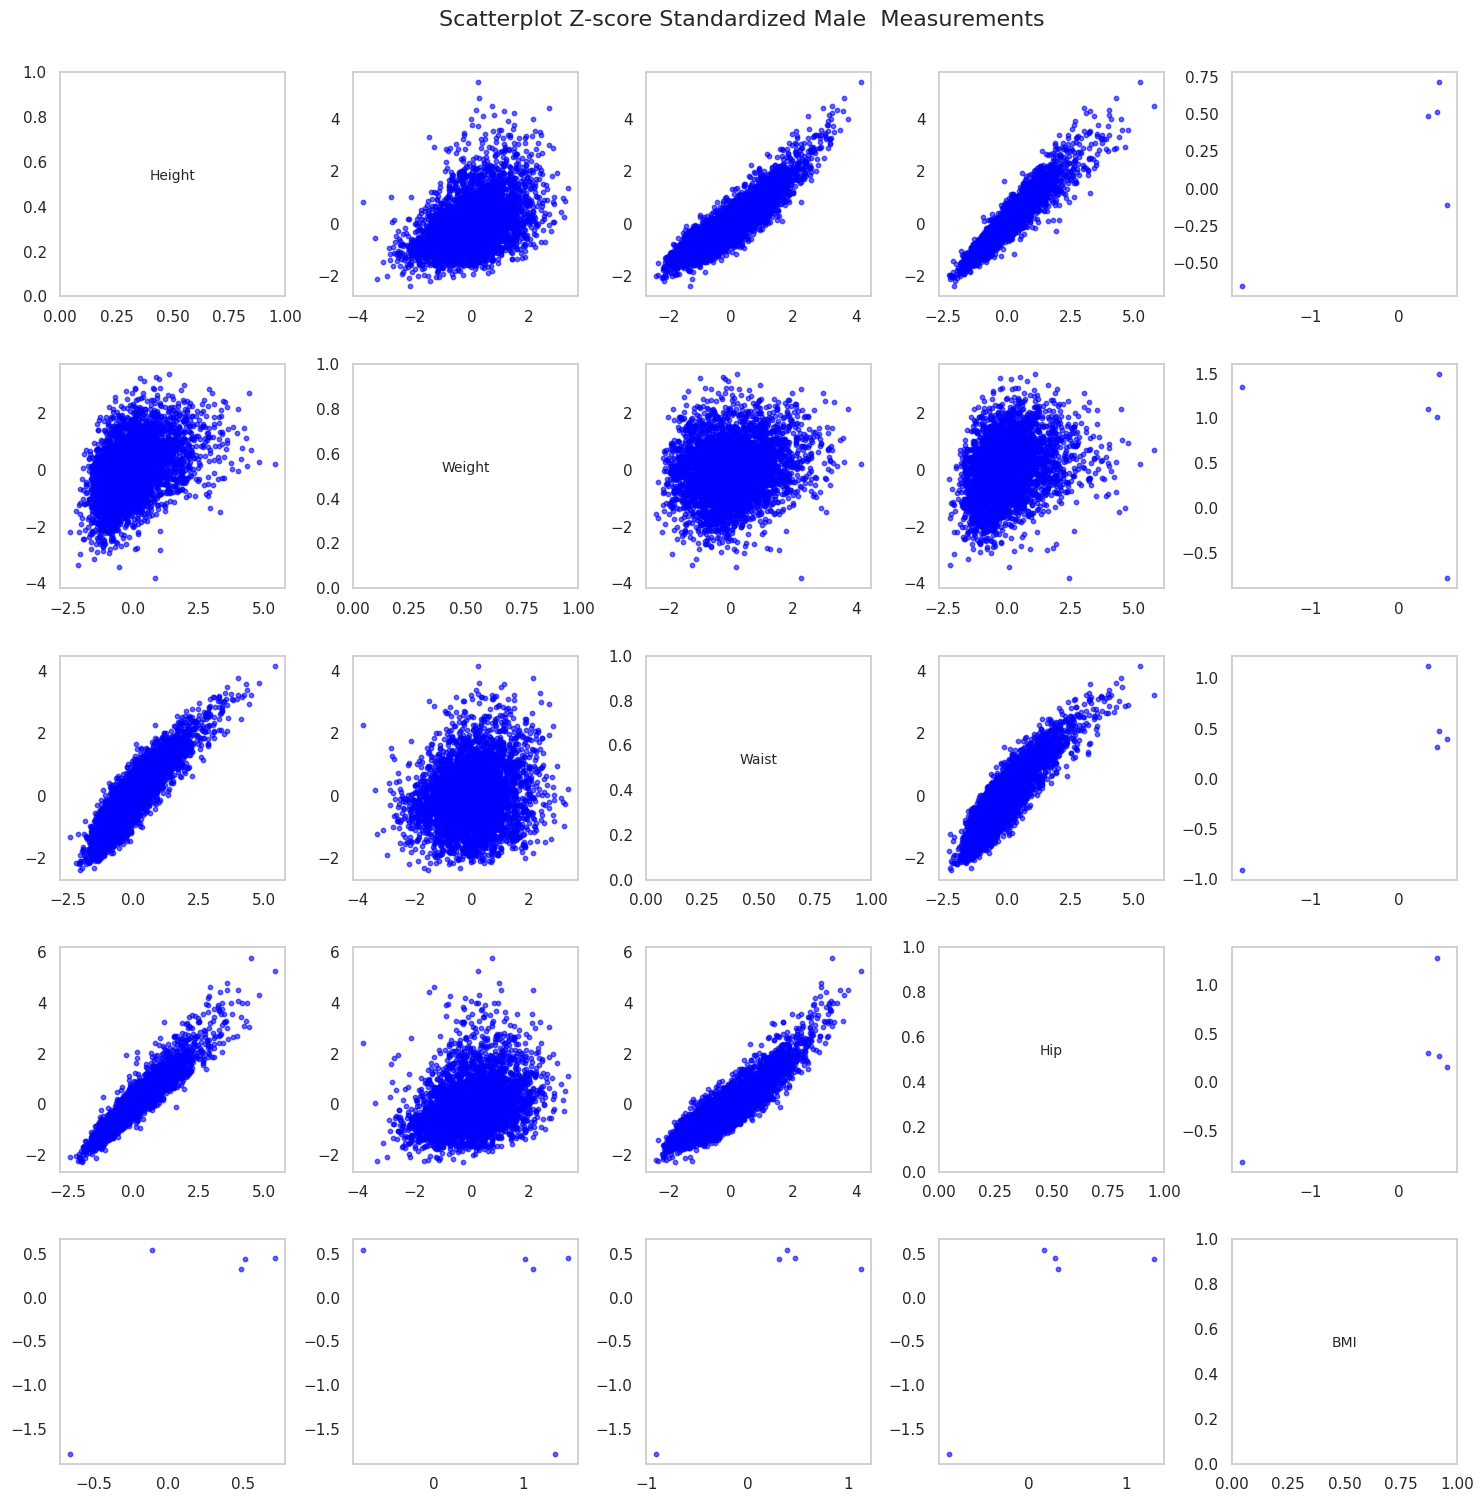

In [20]:
# Create numpy with Zmeal dataset
zmale = (male_df_subset - male_df_subset.mean()) / male_df_subset.std()

num_vars = len(columns)
#plot subplot
fig, axes = plt.subplots(num_vars, num_vars, figsize=(15, 15))
fig.suptitle('Scatterplot Z-score Standardized Male  Measurements', fontsize=16, y=1)

# Loop to plot histograms and scatterplots
for i, j in itertools.product(range(num_vars), repeat=2):
    if i == j:
        # Plot histograms on the diagonal
        #axes[i, j].hist(male_df_subset.iloc[:, i], bins=20, color='skyblue', edgecolor='black')
        axes[i, j].set_title(columns[i], fontsize=10,  va='center', y=0.5)
    else:
        # Plot scatterplots on the off-diagonal
        axes[i, j].scatter(zmale.iloc[:, j], zmale.iloc[:, i], alpha=0.6, s=10, color='blue')
    # Remove gridlines from the Pearson heatmap
    axes[i,j].grid(False)     
    
# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)

# Show the plot
plt.show()

- Create numpy with Zmeal dataset
- plot subplot of matplot lib
- Loop to plot histograms and scatterplots
- Adjust layout to prevent overlap

### Q10 zmale dataset Heatmap

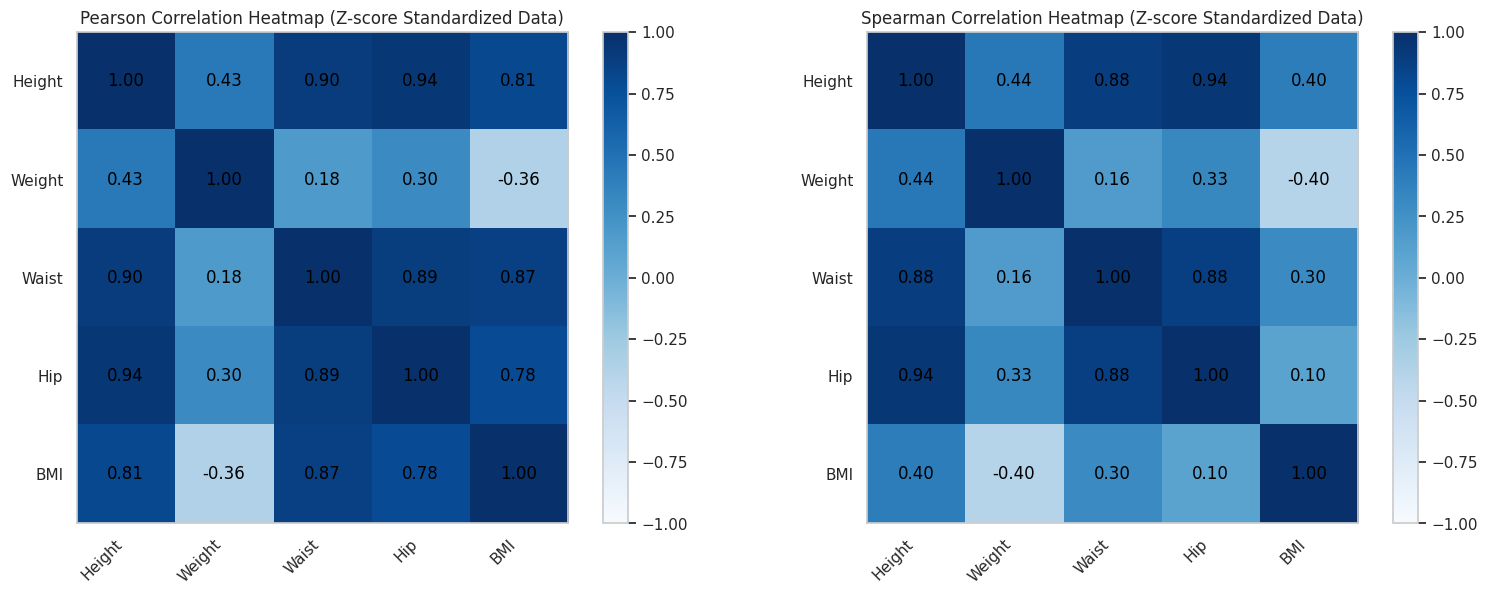

In [21]:
# Compute correlation matrices
pearson_corr_zmale = zmale.corr(method='pearson')
spearman_corr_zmale = zmale.corr(method='spearman')

# Plot the heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson correlation heatmap of Male
cmap = plt.cm.Blues
im1 = axes[0].imshow(pearson_corr_zmale, cmap=cmap, vmin=-1, vmax=1)
fig.colorbar(im1, ax=axes[0])
axes[0].set_title("Pearson Correlation Heatmap (Z-score Standardized Data)")
axes[0].set_xticks(range(len(columns)))
axes[0].set_yticks(range(len(columns)))
axes[0].set_xticklabels(columns, rotation=45, ha="right")
axes[0].set_yticklabels(columns)
for (i, j), val in np.ndenumerate(pearson_corr_zmale.values):
    axes[0].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')

# Remove gridlines from the Pearson heatmap
axes[0].grid(False)

# Spearman correlation heatmap of femal
im2 = axes[1].imshow(spearman_corr_zmale, cmap=cmap, vmin=-1, vmax=1)
fig.colorbar(im2, ax=axes[1])
axes[1].set_title("Spearman Correlation Heatmap (Z-score Standardized Data)")
axes[1].set_xticks(range(len(columns)))
axes[1].set_yticks(range(len(columns)))
axes[1].set_xticklabels(columns, rotation=45, ha="right")
axes[1].set_yticklabels(columns)
for (i, j), val in np.ndenumerate(spearman_corr_zmale.values):
    axes[1].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')

# Remove gridlines from the Pearson heatmap
axes[1].grid(False)

plt.tight_layout()
plt.show()

- Compute correlation matrices of pearson and  spearman of Z-score dataset
- Plot the heatmaps
   - Pearson correlation heatmap of Male
   - Spearman correlation heatmap of femal